<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-header">

## Tutorial \#4: Brains

</div>

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

<b><i>Spark</i></b> defines a very special module called <b>spark.nn.Brain</b>, this module has the sole purpose of constructing and running complex models. Moreover, this is where some of the optimizations that allow <b><i>Spark</i></b>'s models to run fast happen.


It all starts with the observation that Spiking Neural Networks are dynamical models and, a few ideas down the line, we may think of computation as flows of information. Critically, flows are not immediate, this allows us to queue every single module contained in <b>spark.nn.Brain</b> for parallel update at the expense of a slightly larger memory footprint and a small latency; most neural models already incorporate delays anyway, what is another one extra timestep more!. 


Although, we expect most of the models being built through the (spoiler alert) Graph Editor utility. It may be worth to it to explain at least once how construct a <b>spark.nn.Brain</b> through code. <b>spark.nn.Brain</b> are constructed almost identically to the <b>spark.nn.Neuron</b> (from the previous tutorial!).

Let's start with a simple <b>spark.nn.Brain</b> that receives K continuous signals from the environment and produces M actions. For now let's define K and M.
</div>

In [1]:
import sys
sys.path.insert(1, './..')

# Imports
import spark
import jax.numpy as jnp

_K = 64
_M = 3

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

The first thing we need is a way to transform the continuous signals from the virtual environment to a spiking signal. We can use <b>spark.nn.interfaces.PoissonSpiker</b> which is one of the most common ways to map floats to spikes. As before, instead of instantiating the module directly, we need to create a specification of this module for the brain. 
</div>

In [2]:
# Define spiker specs.
spiker_specs = spark.ModuleSpecs(
	name ='spiker',													# <--- Defining a module named 'spikes'
    module_cls = spark.nn.interfaces.PoissonSpiker, 				# <--- The module is of type TopologicalLinearSpiker
	inputs = {														# <--- We need to specify all the inputs of the module
		'signal': [													# <--- PoissonSpiker has a single input named 'signal'
			spark.PortMap(origin='__call__', port='signal'),		# <--- Mappings are defined through PortMap's, which are simply a pair
		]															#      of labels, origin or name of the module producing the input and 
	},																#      port which is the name of the output variable produced by the input
)																	#      module

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Next, we need some neurons to do something interesting. Let's create two simple pool of ALIF (<b>spark.nn.neurons.ALIFNeuron</b>) neurons and connect everything in a forward manner. Additionally, we add some self-recurrency to spice up the model a little bit.

</div>

In [36]:
# ALIF neurons pool.
first_neuron_pool_specs = spark.ModuleSpecs(
	name ='first_pool', 
	module_cls = spark.nn.neurons.ALIFNeuron, 
	inputs = {
		'in_spikes': [
			spark.PortMap(origin='spiker', port='spikes'),				# <--- "first_pool" attends to the output of the "spiker"
		]
	},
	config = spark.nn.neurons.ALIFNeuronConfig(							# <--- It would be useful to also specify the size of the pool
        _s_units = (256,),												#      individually, this can be done by also setting a 
		synapses__kernel__scale = 200,									#      configuration within the ModuleSpecs
		inhibitory_rate = 0.3,
	)																	
)

second_neuron_pool_specs = spark.ModuleSpecs(
	name ='second_pool', 
	module_cls = spark.nn.neurons.ALIFNeuron, 
	inputs = {
		'in_spikes': [
			spark.PortMap(origin='first_pool', port='out_spikes'),		# <--- "second_pool" attends to the output of the "first_pool"
            spark.PortMap(origin='second_pool', port='out_spikes'),		# <--- and to itself...
		]
	},
	config = spark.nn.neurons.ALIFNeuronConfig(
        _s_units = (128,),
        synapses__kernel__scale = 200,
        inhibitory_rate = 0.3,
	)
)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Finally, we need a component to map the activity of our model to an actionable signal. This is easily achivable with an "integrator", in particular, with <b>spark.nn.interfaces.ExponentialIntegrator</b>. This component simply tracks the activity of its inputs over time and maps them to a continuous value (this is done, either by a manually imputed mask or from a random selection of neurons). Let's use only our second pool of neurons for this map.

</div>

In [37]:
# Integrator.
integrator_specs = spark.ModuleSpecs(
	name ='integrator', 
	module_cls = spark.nn.interfaces.ExponentialIntegrator, 
	inputs = {
		'spikes': [
			spark.PortMap(origin='second_pool', port='out_spikes'),
		]
	},
    outputs = {
        'my_awesome_signal': 'signal'
	},
	config = spark.nn.interfaces.ExponentialIntegratorConfig(
		num_outputs = _M,
	)
)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Unlike neurons, we do not typically build a custom object for a <b>spark.nn.Brain</b>. Instead we simply pass the custom configuration to get an instance of a brain.
</div>

In [38]:
# Bundle everything into a list.
modules_specs_list = [
    spiker_specs,
    first_neuron_pool_specs,
    second_neuron_pool_specs,
    integrator_specs,
]
# Create a brain config
brain_config = spark.nn.BrainConfig(
    modules_specs=modules_specs_list
)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

As usual, let's give it a try to see what it does. Note that depending on the complexity of the model this my take a little bit of time, since on the first call, <b>spark.nn.Brain</b> initializes all the arrays and performs some extra validation to ensure that everything is working as intended.
</div>

In [39]:
# Create the brain!
brain = spark.nn.Brain(config=brain_config)

brain(signal=spark.FloatArray(jnp.zeros((_K,), dtype=jnp.float16)))

{'my_awesome_signal': FloatArray(value=Array([0., 0., 0.], dtype=float16))}

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Now, for purely didactic purposes, let's visualize all the activity within the network. Note that, in general, we should not try to record everything, since this will massively slow down the computation, but this is a tutorial after all.

First, we need to create a few jit methods, one to run the network and another one to record from the network.
</div>

In [40]:
import jax
import numpy as np
import typing as tp
from functools import partial

# Utility function to execute brain efficiently.
@jax.jit
def run_model(graph, state, **inputs) -> tuple[dict, tp.Any]:
	model = spark.merge(graph, state)
	out = model(**inputs)
	_, state = spark.split((model))
	return out, state

# Utility function to retrieve data from the model.
@partial(jax.jit, static_argnames=('read_ports'))
def retrieve_spikes(graph, state, read_ports: tuple[spark.PortMap]) -> dict:
	model: spark.nn.Brain = spark.merge(graph, state)
	# Read state returns a dictionary of the current value in the cache for every element in read_ports
	readout = model.read_state(read_ports)

	# PROTIP: We may do a small preprocessing inside the jitted function.
	# This is handcrafted to place the spikes in order that we want.
	readout_spikes = jnp.concatenate([
		readout['spiker']['spikes'].value,
		readout['first_pool']['out_spikes'].value,
		readout['second_pool']['out_spikes'].value,
	])

	return readout_spikes

# Note that this needs to be a tuple!
READOUT = (
	spark.PortMap('spiker', 'spikes'),
	spark.PortMap('first_pool', 'out_spikes'),
	spark.PortMap('second_pool', 'out_spikes'),
)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Next, let's run the brain for a few steps and collect the spikes!.

</div>

In [127]:
# Split into a graph and a state
graph, state = spark.split((brain))

# Set some signal. Since PoissonSpiker is stochastic, there is no need for us to update this value to get something interesting. 
signal = spark.FloatArray(jnp.array(np.random.rand(_K,), dtype=jnp.float16))

readout_spikes = []
outputs = []
for i in range(500):
	out, state = run_model(graph, state, signal=signal)
	readout = retrieve_spikes(graph, state, READOUT)
	readout_spikes.append(np.array(readout))
	outputs.append(out['my_awesome_signal'].value)
readout_spikes = np.array(readout_spikes)
outputs = np.array(outputs)

# Let's use a softmax to transform the continuous signal to action probabilities
def softmax(x):
	return np.exp(x)/np.sum(np.exp(x), axis=1, keepdims=True)

action_prob = softmax(outputs)

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

Finally, let's plot the spikes!.

</div>

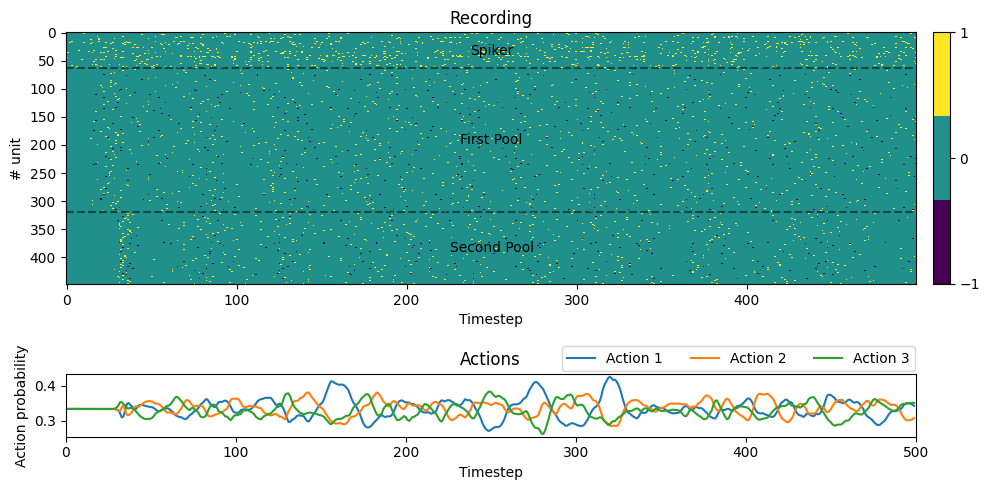

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

concat_units, max_time = readout_spikes.T.shape

cmap = plt.get_cmap('viridis', 3)
fig, axs = plt.subplots(2,1,figsize=(10,5), height_ratios=[4,1])

# Plot spike recordings
im = axs[0].imshow(readout_spikes.T, aspect='auto', interpolation='none', cmap=cmap, vmin=-1, vmax=1)
axs[0].plot([-0.5, max_time-0.5], [_K-0.5, _K-0.5], 'k--', alpha=0.5)
axs[0].plot([-0.5, max_time-0.5], [256+_K-0.5, 256+_K-0.5], 'k--', alpha=0.5)

# Format recordings plot
axs[0].text(max_time/2, _K/2, 'Spiker', va='center', ha='center')
axs[0].text(max_time/2, 256/2+_K, 'First Pool', va='center', ha='center')
axs[0].text(max_time/2, 128/2+256+_K, 'Second Pool', va='center', ha='center')
axs[0].set_ylabel('# unit')
axs[0].set_xlabel('Timestep')
axs[0].set_title('Recording')
ax0_divider = make_axes_locatable(axs[0])
cax0 = ax0_divider.append_axes("right", size="2%", pad="2%")
fig.colorbar(im, cax=cax0, ticks=[1,0,-1])

# Plot action probabilities
l1, = axs[1].plot(action_prob[:,0], label='Action 1')
l2, = axs[1].plot(action_prob[:,1], label='Action 2')
l3, = axs[1].plot(action_prob[:,2], label='Action 3')
# Format actions plot
axs[1].set_xlim(0, max_time)
axs[1].set_ylabel('Action probability')
axs[1].set_xlabel('Timestep')
axs[1].set_title('Actions')
axs[1].legend(ncols=3, bbox_to_anchor=(0.5075, 1.05, 0.5, 0.5))

ax1_divider = make_axes_locatable(axs[1])
cax1 = ax1_divider.append_axes("right", size="2%", pad="2%")
cax1.axis('off')

plt.tight_layout()
plt.show()

<link rel="stylesheet" type="text/css" href="./style.css">

<div class="tutorial-text">

As we can see, first the spiker detects our signal and starts producing spikes. These spikes are propagated to the first pool but note that neurons in this pool first need to start accumulating charge before starting to fire; similarly for the second pool, in which neurons take even loger to fire. 

Now, since the actions that that the model produce are computed with a softmax of the activity of the second pool, the model will first produce a uniform probability distribution until the activity on the second pool ramps up. Then it will go on on producing a somewhat random distribution, centered around 1/3, since the input to the networks is a random distribution of spikes.

🎉 Congratulations! 🎉 

You built your first SNN that does absolutely nothing interesting (but progress is still progress) !



</div>